# Parte 3: Modelos Multimodales

**Objetivo:** Desplegar un modelo y probar interacciones que involucren imágenes y texto combinado.

### Configuración de entorno y modelos

In [1]:
import os
import base64
import json
from openai import AzureOpenAI
from dotenv import load_dotenv
from IPython.display import Image, display

# 1. Configuración del cliente mediante variables de entorno
load_dotenv()

client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),  
    api_version="2024-08-01-preview",
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT")
)

# Usamos el nombre del deployment definido en el .env
deployment_multimodal = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")

### 3.1 Procesamiento de Imágenes (Visión)
Para enviar una imagen al modelo, la convertimos a formato Base64 y la incluimos en el cuerpo del mensaje junto con un prompt de texto.

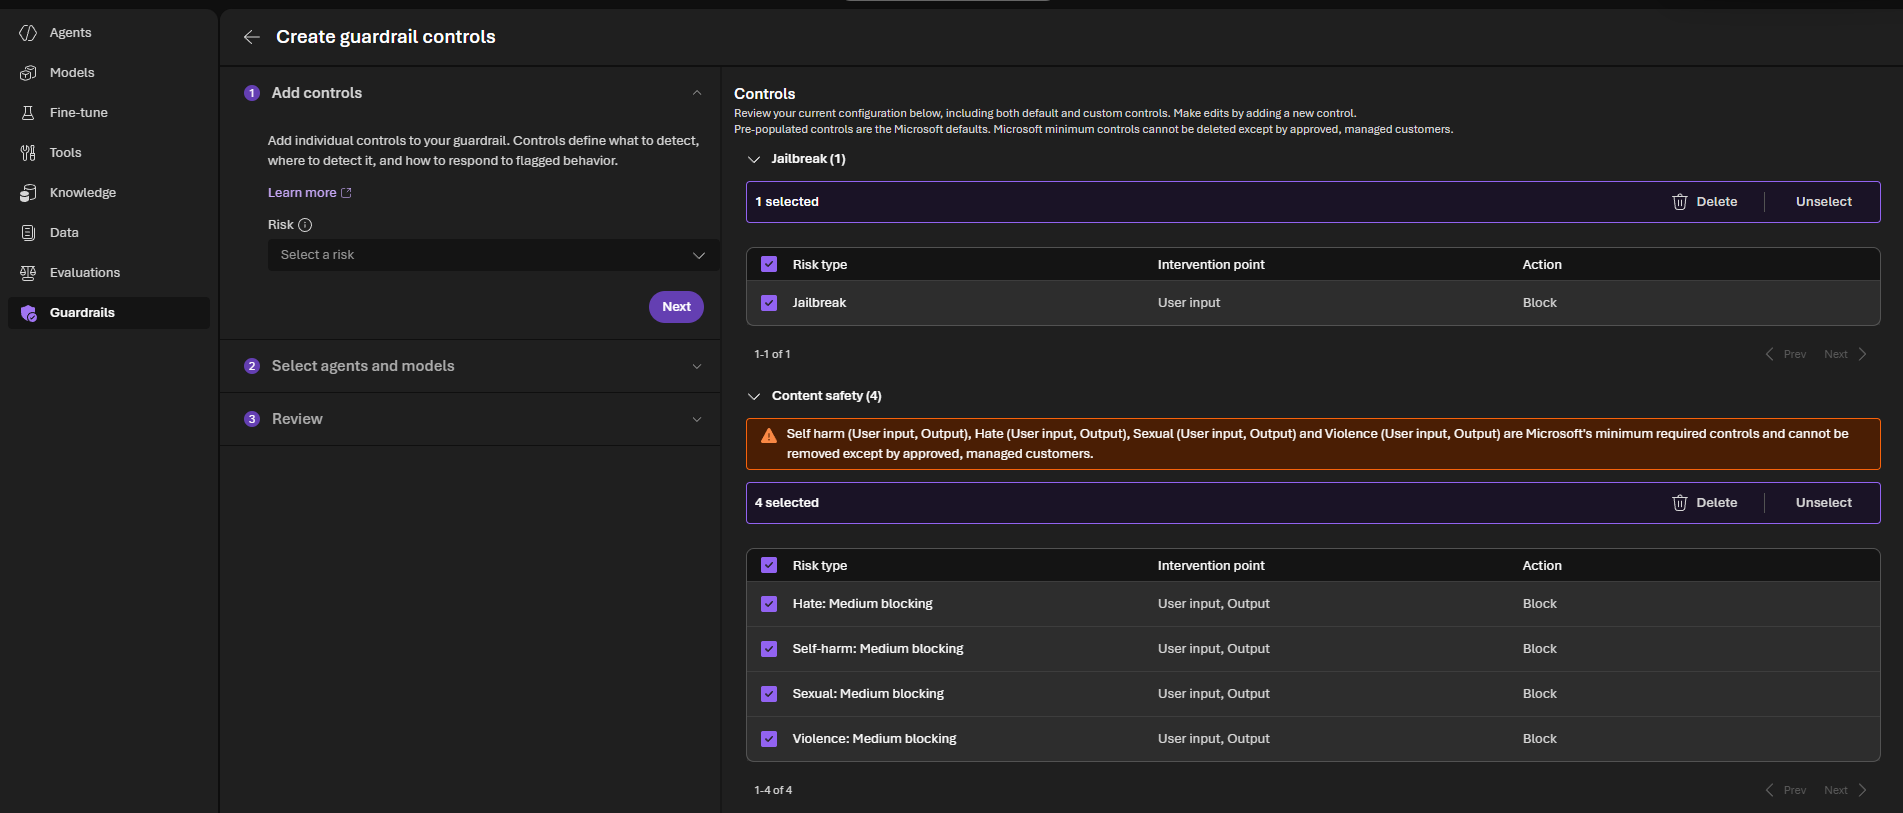


Respuesta del Modelo:
En la imagen de Azure AI Foundry se observa la configuración de controles de seguridad, específicamente en la sección de "Guardrails". Se han establecido controles para gestionar ciertos riesgos.

### Configuración de Seguridad:
1. **Jailbreak**: Hay un control específico activo para prevenir intentos de "jailbreak", lo que implica bloquear entradas que intenten eludir las restricciones del sistema.
  
2. **Contenido Seguro**: Se incluyen cuatro tipos de bloqueos relacionados con la seguridad del contenido, específicamente:
   - **Autolesiones (Self-harm)**: Bloqueo de entradas y salidas que mencionen autolesiones.
   - **Odio (Hate)**: Bloqueo de contenidos que promuevan odio, tanto en entradas como salidas.
   - **Contenido Sexual (Sexual)**: Filtrado de contenido sexual, también en entradas y salidas.
   - **Violencia (Violence)**: Bloqueo de cualquier contenido relacionado con la violencia, en ambas direcciones.

### Filtros Bloqueados:
Todos los filtros menc

In [5]:
def encode_image(image_path):
    """Convierte una imagen local en una cadena base64"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

image_file = "img/guardrails.png"

try:
    display(Image(filename=image_file, width=600))
    
    base64_image = encode_image(image_file)

    # Llamada multimodal
    response = client.chat.completions.create(
        model=deployment_multimodal,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Describe qué configuración de seguridad se observa en esta imagen de Azure AI Foundry y qué filtros están bloqueando contenido."},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_image}"
                        }
                    }
                ]
            }
        ],
        max_tokens=500
    )

    print("\nRespuesta del Modelo:")
    print(response.choices[0].message.content)

except FileNotFoundError:
    print(f"Error: El archivo {image_file} no se encuentra en el directorio.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")